# **Parsing .fsexp FusionScope HDF5 Experiment Files**

Created on Fri Jul 31 2026

Author: Aidan Swanger

In [2]:
# Install SciFiReaders
%pip install --no-cache-dir git+https://github.com/pycroscopy/SciFiReaders.git@main

<IPython.core.display.Javascript object>

  Cloning https://github.com/aswanger011/SciFiReadersAS.git (to revision main) to /tmp/pip-req-build-t0fkwv5v
  Running command git clone --filter=blob:none --quiet https://github.com/aswanger011/SciFiReadersAS.git /tmp/pip-req-build-t0fkwv5v
  Resolved https://github.com/aswanger011/SciFiReadersAS.git to commit 2c4bd86eef59e4ee837f776c015361227a0926a9
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of dask[array,dataframe] to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.0/128.0 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 76.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 153.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.9/69.9 kB 167.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
# Imports
from SciFiReaders import FSexpReader

<IPython.core.display.Javascript object>

In [4]:
# Upload test file from github
!wget https://raw.githubusercontent.com/pycroscopy/SciFiDatasets/main/data/microscopy/spm/afm/test_FSexp.fsexp

<IPython.core.display.Javascript object>

--2026-07-31 19:54:43--  https://raw.githubusercontent.com/aswanger011/SciFiDatasetsAS/main/data/microscopy/spm/afm/test_FSexp.fsexp
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12968094 (12M) [application/octet-stream]
Saving to: ‘test_FSexp.fsexp’

test_FSexp.fsexp    100%[===================>]  12.37M  --.-KB/s    in 0.1s    

2026-07-31 19:54:44 (107 MB/s) - ‘test_FSexp.fsexp’ saved [12968094/12968094]



In [5]:
# Initialize reader
reader = FSexpReader("test_FSexp.fsexp")

<IPython.core.display.Javascript object>

In [6]:
# Read file
reader.read()

<IPython.core.display.Javascript object>

{'000_1_OverviewFrame': sidpy.Dataset of type IMAGE with:
  dask.array<array, shape=(1000, 1000), dtype=float32, chunksize=(1000, 1000), chunktype=numpy.ndarray>
  data contains: 000_1_OverviewFrame (arb.u.)
  and Dimensions: 
 x:  x-axis (um) of size (1000,)
 y:  y-axis (um) of size (1000,)
  with metadata: ['key', 'dataset_info', 'region_info', 'frame_info'],
 '001_SEM_Secondary_Electron': sidpy.Dataset of type IMAGE with:
  dask.array<array, shape=(2000, 2000), dtype=float32, chunksize=(2000, 2000), chunktype=numpy.ndarray>
  data contains: 001_SEM_Secondary_Electron (arb.u.)
  and Dimensions: 
 x:  x-axis (um) of size (2000,)
 y:  y-axis (um) of size (2000,)
  with metadata: ['key', 'dataset_info', 'region_info', 'frame_info'],
 '002_AFM_Topography_(Trace)': sidpy.Dataset of type IMAGE with:
  dask.array<array, shape=(128, 128), dtype=float32, chunksize=(128, 128), chunktype=numpy.ndarray>
  data contains: 002_AFM_Topography_(Trace) (um)
  and Dimensions: 
 x:  x-axis (um) of size 

## **Overview**

**FusionScope .fsexp HDF5 Experiment files** store all images and image data from one use of the microscope into a single file.  This means the reader must go through that file and label and extract all image data from it.



---



## **Key Naming Convention**

Each dictionary key follows this pattern:
              
              00N_Name
*   N = the sequential number of the measurement (e.g., 001, 002, ...)
*   Name = the full original measurement name from the .fsexp file (e.g. AFM_Topography_(Trace))



---



## **Output Structure**

The reader returns a Python dictionary where each key represents a separate single scan from the file.  

Each entry is represented by a sidpy.Dataset, which includes the data and metadata.

Learn more about sidpy format and pycroscopy: [pycroscopy](https://pycroscopy.github.io/pycroscopy/ecosystem.html)

## **Image**

In [16]:
# Single scan sidpy.Dataset
data = reader.read()
scan = data["001_SEM_Secondary_Electron"]
print(scan)

<IPython.core.display.Javascript object>

sidpy.Dataset of type IMAGE with:
 dask.array<array, shape=(2000, 2000), dtype=float32, chunksize=(2000, 2000), chunktype=numpy.ndarray>
 data contains: 001_SEM_Secondary_Electron (arb.u.)
 and Dimensions: 
x:  x-axis (um) of size (2000,)
y:  y-axis (um) of size (2000,)
 with metadata: ['key', 'dataset_info', 'region_info', 'frame_info']


In [17]:
# Single scan NumPy array
scan.compute()

<IPython.core.display.Javascript object>

array([[0.1962005 , 0.17320515, 0.17402914, ..., 0.19429313, 0.17633326,
        0.17555505],
       [0.1833219 , 0.16270696, 0.17198443, ..., 0.180148  , 0.15785459,
        0.18260472],
       [0.16655223, 0.15623713, 0.15963988, ..., 0.16969559, 0.16971084,
        0.17265584],
       ...,
       [0.1714046 , 0.1728542 , 0.17230487, ..., 0.17187762, 0.19816892,
        0.1950103 ],
       [0.16520943, 0.17447166, 0.1841764 , ..., 0.1785153 , 0.18844892,
        0.19418631],
       [0.1728542 , 0.17222857, 0.18423744, ..., 0.17312886, 0.1906157 ,
        0.18013275]], dtype=float32)

<IPython.core.display.Javascript object>

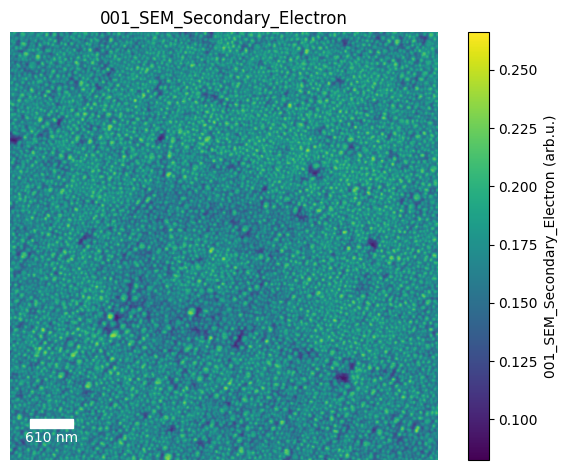

In [18]:
# Single SEM scan visualization
scan.plot(scale_bar = True, cmap = 'viridis');

<IPython.core.display.Javascript object>

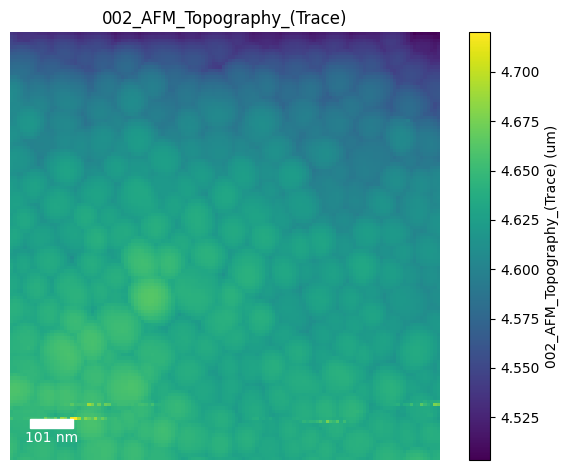

In [19]:
# Single AFM scan visualization
scan = data["002_AFM_Topography_(Trace)"]

scan.plot(scale_bar = True, cmap = 'viridis');

<IPython.core.display.Javascript object>

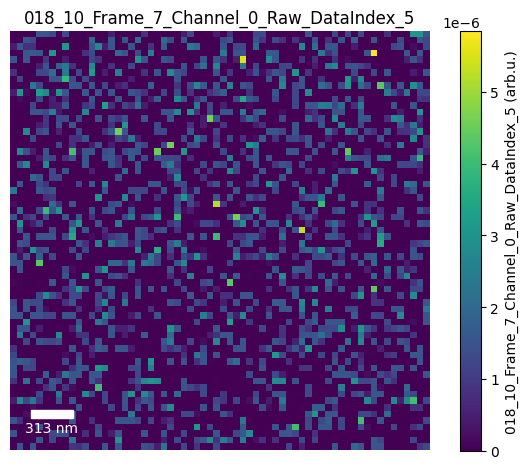

In [20]:
# Single EDS map scan visualization
scan = data["018_10_Frame_7_Channel_0_Raw_DataIndex_5"]

scan.plot(scale_bar = True, cmap = 'viridis');

## **Single Scan Metadata**

In [21]:
# Single SEM scan
scan = data["001_SEM_Secondary_Electron"]

<IPython.core.display.Javascript object>

In [22]:
# Summarized single scan metadata
scan.metadata

<IPython.core.display.Javascript object>

{'key': '001_SEM_Secondary_Electron',
 'dataset_info': {'key': '001_SEM_Secondary_Electron',
  'index': '001',
  'region_name': '1_Region_1',
  'frame_name': '1_Frame_1_Channel_0',
  'processing_state': 'Raw',
  'data_index_name': 'DataIndex_0',
  'shape': (2000, 2000),
  'dtype': 'float32',
  'subchannel_name': 'SEM Secondary Electron',
  'image_range': array([0.08253605, 0.26614785], dtype=float32),
  'display_origin': np.bytes_(b'UL'),
  'path': '/PipelineData/1_Region_1/SourceFrames/1_Frame_1_Channel_0/Raw/DataIndex_0'},
 'region_info': {'regionName': 'Auto-Saved Scan',
  'regionDescription': 'Auto-saved @ 20260731-114822',
  'regionWidth': 6.101858139038086,
  'regionHeight': 6.101858139038086,
  'regionUnits': '',
  'regionXOrigin': -64.3509162068367,
  'regionYOrigin': -74.75094324350357,
  'rotationAngle': -0.0003376007080078125},
 'frame_info': {'frame_number': 1,
  'channel': 0,
  'frameType': 0,
  'frame_valid': True,
  'samplesPerLine': 2000,
  'num_lines': 2000,
  'actual_

In [23]:
# Original full single scan metadata
scan.original_metadata

<IPython.core.display.Javascript object>

{'key': '001_SEM_Secondary_Electron',
 'dataset_info': {'key': '001_SEM_Secondary_Electron',
  'index': '001',
  'path': '/PipelineData/1_Region_1/SourceFrames/1_Frame_1_Channel_0/Raw/DataIndex_0',
  'region_name': '1_Region_1',
  'frame_name': '1_Frame_1_Channel_0',
  'processing_state': 'Raw',
  'data_index_name': 'DataIndex_0',
  'shape': (2000, 2000),
  'dtype': 'float32',
  'attrs': {'CLASS': np.bytes_(b'IMAGE'),
   'DISPLAY_ORIGIN': np.bytes_(b'UL'),
   'IMAGE_MINMAXRANGE': array([0.08253605, 0.26614785], dtype=float32),
   'IMAGE_SUBCLASS': np.bytes_(b'IMAGE_GRAYSCALE'),
   'IMAGE_VERSION': np.bytes_(b'1.2'),
   'IMAGE_WHITE_IS_ZERO': np.uint8(0),
   'SUBCHANNEL_NAME': 'SEM Secondary Electron'}},
 'region_info': {'regionDescription': 'Auto-saved @ 20260731-114822',
  'regionHeight': 6.101858139038086,
  'regionIsCorrelated': False,
  'regionName': 'Auto-Saved Scan',
  'regionSaveCount': 1,
  'regionSaveId': 1,
  'regionType': 1,
  'regionUnits': '',
  'regionWidth': 6.1018581390

## **In-depth .fsexp File Data Structure**

```text
.fsexp file
│
├── Root attributes
│   ├── EXPERIMENT_INFO
│   ├── APPLICATION_VERSION
│   ├── EXPERIMENT_FILE_VERSION
│   ├── OVERVIEW_RECT
│   └── Additional attributes
│
├── PipelineData
│   │
│   ├── OverviewRegion
│   │   ├── Attribute: REGION_INFO
│   │   │
│   │   └── SourceFrames
│   │       │
│   │       └── Frame_Name
│   │           ├── Attribute: FRAME_INFO
│   │           │
│   │           ├── Raw
│   │           │   ├── DataIndex_0
│   │           │   ├── DataIndex_1
│   │           │   └── Additional datasets
│   │           │
│   │           └── Processed
│   │               ├── DataIndex_0
│   │               ├── DataIndex_1
│   │               └── Additional datasets
│   │
│   ├── Numbered_Region
│   │   ├── Attribute: REGION_INFO
│   │   │
│   │   └── SourceFrames
│   │       │
│   │       ├── 1_Frame_0_Channel_0
│   │       │   ├── Attribute: FRAME_INFO
│   │       │   ├── Raw
│   │       │   │   └── DataIndex_0
│   │       │   └── Processed
│   │       │       └── DataIndex_0
│   │       │
│   │       └── Additional frames
│   │
│   └── Additional regions
│
└── Other top-level HDF5 objects
```